In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import EMNIST
from torchvision import transforms
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split


In [3]:
# Load and preprocess EMNIST
transform = transforms.Compose([transforms.ToTensor()])
train_data = EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_data = EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

# Convert to NumPy and flatten
X_train = train_data.data.numpy().reshape(-1, 28*28)
y_train = train_data.targets.numpy()
X_test = test_data.data.numpy().reshape(-1, 28*28)
y_test = test_data.targets.numpy()

# Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15)


100%|██████████| 562M/562M [00:46<00:00, 12.1MB/s] 


In [4]:
# evaluate function from lek17_trees.ipynb
def evaluate(H, Y, beta=1.0):
   tp = sum((Y == H) * (Y == 1) * 1)
   tn = sum((Y == H) * (Y == 0) * 1)
   fp = sum((Y != H) * (Y == 0) * 1)
   fn = sum((Y != H) * (Y == 1) * 1)

   accuracy = (tp + tn) / (tp + fp + fn + tn)
   sensitivity = tp / (tp + fn)
   specificity = tn / (fp + tn)
   precision = tp / (tp + fp)
   recall = sensitivity
   f_score = ( (beta**2 + 1) * precision * recall) / (beta**2 * precision + recall)
   auc = (sensitivity + specificity) / 2
   youden = sensitivity - (1 - specificity)
   p_plus = sensitivity / (1 - specificity)
   p_minus = (1 - sensitivity) / specificity
   dp = (np.sqrt(3) / np.pi) * (np.log(sensitivity/(1 - sensitivity) + np.log(specificity/(1 - specificity))))

   result = {}
   result["tp"] = tp
   result["tn"] = tn
   result["fp"] = fp
   result["fn"] = fn
   result["accuracy"] = accuracy
   result["sensitivity"] = sensitivity
   result["specificity"] = specificity
   result["precision"] = precision
   result["recall"] = recall
   result["f-score"] = f_score
   result["AUC"] = auc
   result["Youden"] = youden
   result["p+"] = p_plus
   result["p-"] = p_minus
   result["DP"] = dp

   return result


In [5]:
decisionTreeCriteria = "gini"
models = [('Decision Tree', DecisionTreeClassifier(criterion=decisionTreeCriteria, max_depth=10)),
          ]


In [6]:
for name, model in models:
    print(f'** {name}')
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    # The evaluation function is designed for binary classification (Y==1, Y==0)
    # Since EMNIST is multi-class, f-score might not work as intended here.
    # However, keeping the loop structure as requested.
    # print(evaluate(train_pred, y_train)['f-score'])
    # print(evaluate(val_pred, y_val)['f-score'])
    print(f"Train Accuracy: {model.score(X_train, y_train)}")
    print(f"Val Accuracy: {model.score(X_val, y_val)}")


** Decision Tree
Train Accuracy: 0.5826449728827702
Val Accuracy: 0.5377659574468086


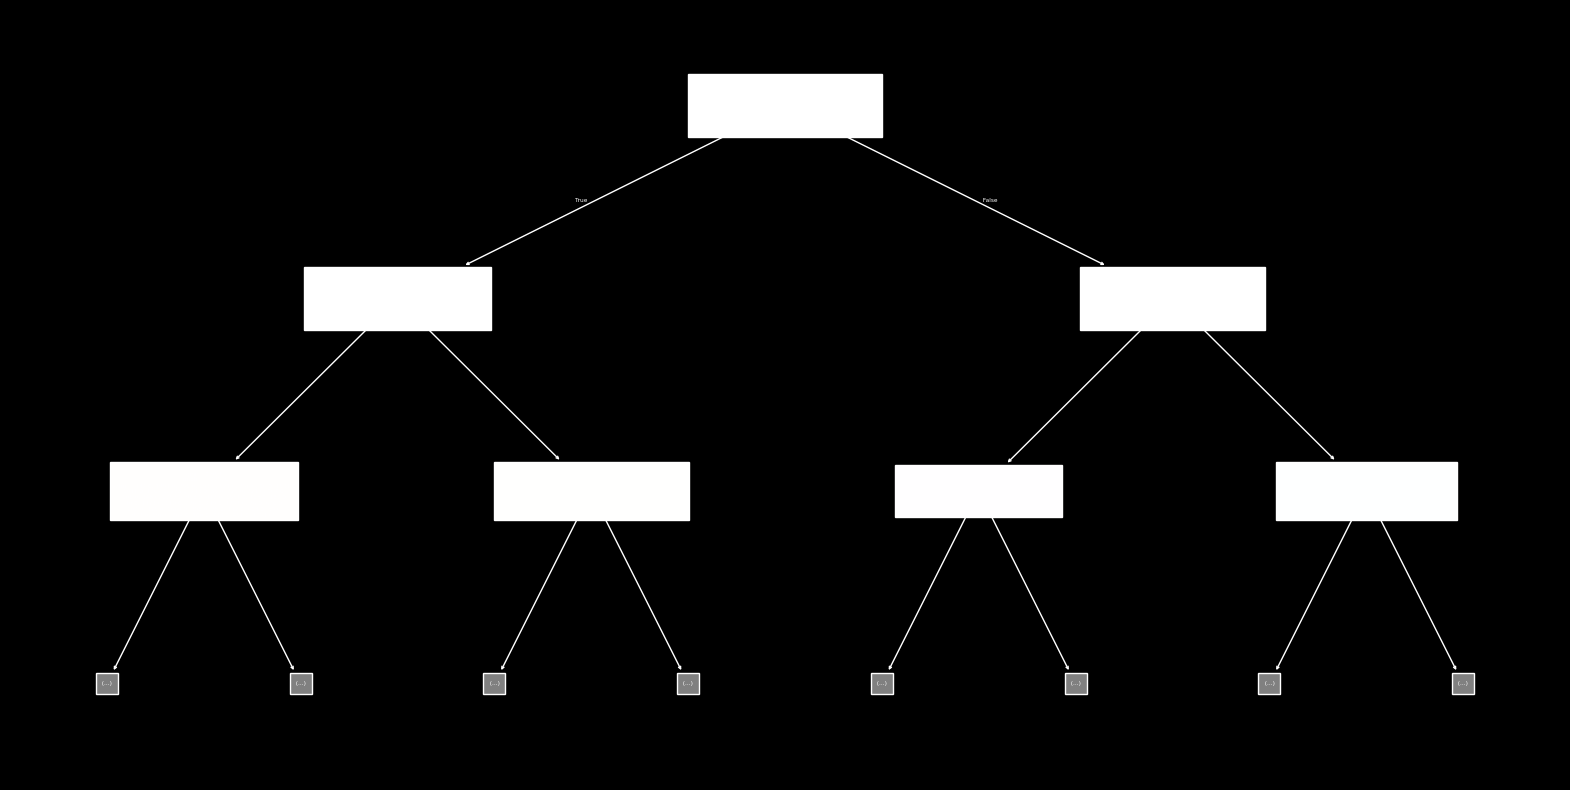

In [7]:
plt.figure(figsize=(20,10))
plot_tree(models[0][1], max_depth=2, feature_names=[f"pixel_{i}" for i in range(784)], filled=True)
plt.show()
